# Import datasets

In [1]:
import pandas as pd
df = pd.read_csv('lazada_products_raw.csv')
# print(df.head())

# Xử lý dữ liệu

## Xử lý cột "discount"

In [2]:
# Trích số % từ cột discount, nếu không có thì gán là 0
df['discount'] = df['discount'].str.extract(r'(\d+)', expand=False)
df['discount'] = df['discount'].fillna(0).astype(int)

# print(df.head())

## Xử lý cột "price"

In [3]:
# Làm sạch và chuyển giá sang số nguyên
df['price'] = df['price'].str.replace(r'[^\d]', '', regex=True).astype(int)

print(df.head())

                                                 url  \
0  https://www.lazada.vn/products/pdp-i3112290630...   
1  https://www.lazada.vn/products/pdp-i3111838730...   
2  https://www.lazada.vn/products/pdp-i3111829485...   
3  https://www.lazada.vn/products/pdp-i3111790648...   
4  https://www.lazada.vn/products/pdp-i3111772655...   

                                                name  discount     price  \
0  Điện Thoại Samsung Galaxy S23 FE 5G (8GB/128GB...        43   3899000   
1  Điện Thoại HONOR X9A 5G (8GB/256GB) Chính hãng...        46   3499000   
2  Điện thoại Samsung S24 FE 5G (8Gb/128Gb) Chính...        29  11990000   
3  Điện Thoại HONOR X9A 5G (8GB/256GB) Chính hãng...        46   3599000   
4  Điện Thoại ZTE Libero Flip 5G (6GB/128GB) Chín...        32   3199000   

  location                                          image_url  
0   Hà Nội  https://img.lazcdn.com/g/p/e811068eabcb8171a28...  
1   Hà Nội  https://img.lazcdn.com/g/p/b4fdbbe41041e03d6ed...  
2   Hà Nội  ht

## Xử lý cột "name"

In [4]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import defaultdict

In [5]:
def preprocess_text(text):
    if not isinstance(text, str):
        text = str(text)

    # Chuẩn hóa tên thương hiệu
    replacements = {
        r'0PP0': 'OPPO ',
        r'Opp0': 'OPPO ',
        r'OPPO\s*': 'OPPO ',
        r'Viv0': 'Vivo ',
        r'Vivo\s*': 'Vivo ',
        r'ss': 'Samsung ',
        r'Ss': 'Samsung ',
        r'SS': 'Samsung ',
        r'SS_': 'Samsung ',
        r'Samsung\s*': 'Samsung ',
        r'Apple\s*': 'Apple ',
        r'Redmi_n0te': 'Redmi Note ',
        r'Red\.mi': 'Redmi ',
        r'P0c0': 'POCO ',
        r'mi Mi': 'Xiaomi ',
        r'pr0': 'Pro ',
        r'pro\s*': 'Pro ',
        r'f0ld': 'Fold ',
    }

    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # Chỉ loại bỏ ký tự KHÔNG phải chữ, số, khoảng trắng và các dấu: / - + =
    text = re.sub(r'[^a-zA-Z0-9\s/\-+=]', ' ', text)

    # Rút gọn khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaned_name'] = df['name'].apply(preprocess_text)
df.to_csv('cleaned_phone_products.csv', index=False)



In [6]:
# Bước 2: Trích xuất thông số kỹ thuật và bảo hành
def extract_specs(text):
    specs = {
        'ram': None,
        'rom': None,
        'battery': None,
        'network': None,
        'sim': None
    }
    
    # Trích xuất RAM/ROM
    ram_rom_match = re.search(r'(\d+GB)\s*[/-]\s*(\d+GB)', text, re.IGNORECASE)
    if ram_rom_match:
        specs['ram'], specs['rom'] = ram_rom_match.groups()
    
    # Trích xuất dung lượng pin
    battery_match = re.search(r'pin\s*(\d+\s*mAh)', text, re.IGNORECASE)
    if battery_match:
        specs['battery'] = battery_match.group(1)
    
    # Trích xuất thông tin mạng
    if '5G' in text:
        specs['network'] = '5G'
    
    # Trích xuất thông tin sim
    sim_match = re.search(r'(\d+)sim', text, re.IGNORECASE)
    if sim_match:
        specs['sim'] = sim_match.group(1)
    
    return specs

def extract_warranty(text):
    match = re.search(r'(\d+)\s*tháng', text, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)\s*năm', text, flags=re.IGNORECASE)
    if match:
        return int(match.group(1)) * 12
    return 0

# Áp dụng hàm trích xuất
specs_df = df['cleaned_name'].apply(lambda x: pd.Series(extract_specs(x)))
df['warranty_months'] = df['cleaned_name'].apply(extract_warranty)
df = pd.concat([df, specs_df], axis=1)

In [7]:
import re

brands = ['Samsung', 'OPPO', 'Xiaomi', 'Redmi', 'POCO', 'Vivo', 'HONOR', 'ZTE', 'Nubia', 'Realme', 'Apple', 'Huawei', 'Asus', 'Sony', 'Motorola', 'Google', 'HTC', 'LG', 'Lenovo', 'OnePlus']
stop_words = ['chính', 'ram', 'rom', 'full', 'seal', 'bản', 'hãng', 'mới', '100', 'cấu', 'hình', 'pin', 'máy', 'bảo', 'hành', 'hàng', 'bh']
ram_rom_pattern = re.compile(r'^\d+(gb|g)$', re.IGNORECASE)

def detect_brand(text):
    text = text.lower()
    for brand in brands:
        if brand.lower() in text:
            return brand
    return 'Unknown'

def extract_model(text, brand):
    if brand == 'Unknown':
        return None
    text = text.lower()

    # Làm sạch ký tự đặc biệt như -, _, +, =
    text = re.sub(r'[^\w\s/]', ' ', text)
    text = re.sub(r'[_+=-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tìm cụm từ sau brand, tối đa 5 từ
    pattern = re.compile(rf'{brand.lower()}\s+((?:[a-z0-9]+\s*){{1,5}})', re.IGNORECASE)
    match = pattern.search(text)
    if match:
        model_raw = match.group(1).strip()
        tokens = model_raw.split()

        # Lọc stop words và các token chứa RAM/ROM
        clean_tokens = []
        for token in tokens:
            if token.lower() in stop_words or ram_rom_pattern.match(token):
                break
            clean_tokens.append(token)

        if not clean_tokens:
            return None

        # Lấy tối đa 2 từ đầu tiên
        return ' '.join(clean_tokens[:3])

    return None

# Áp dụng vào DataFrame
df['brand'] = df['cleaned_name'].apply(detect_brand)
df['model'] = df.apply(lambda row: extract_model(row['cleaned_name'], row['brand']), axis=1)


In [8]:
# Bước 4: Làm sạch final
def clean_model_name(model):
    if pd.isna(model):
        return model
    # Loại bỏ thông số kỹ thuật nằm trong tên model
    model = re.sub(r'\d+\s*GB', '', model, flags=re.IGNORECASE)
    model = re.sub(r'pin\s*\d+\s*mAh', '', model, flags=re.IGNORECASE)
    model = re.sub(r'\d+\s*sim', '', model, flags=re.IGNORECASE)
    model = re.sub(r'\b5G\b', '', model, flags=re.IGNORECASE)

    # Chuẩn hoá khoảng trắng
    model = re.sub(r'\s+', ' ', model).strip()
    return model

df['model'] = df['model'].apply(clean_model_name)

# Chọn các cột quan trọng cho output
clean_df = df[['url', 'brand', 'model', 'ram', 'rom', 'battery', 'network', 'sim', 'warranty_months', 'discount', 'price', 'location', 'image_url']]
# Lưu kết quả vào file CSV
clean_df.to_csv('final_cleaned_phone_products.csv', index=False)

# Trực quan hoá dữ liệu

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dữ liệu
df = pd.read_csv("final_cleaned_phone_products.csv")

# Chuyển các cột số sang định dạng số (bỏ giá trị rỗng)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['warranty_months'] = pd.to_numeric(df['warranty_months'], errors='coerce')


## Biểu đồ số lượng sản phẩm theo hãng (brand)

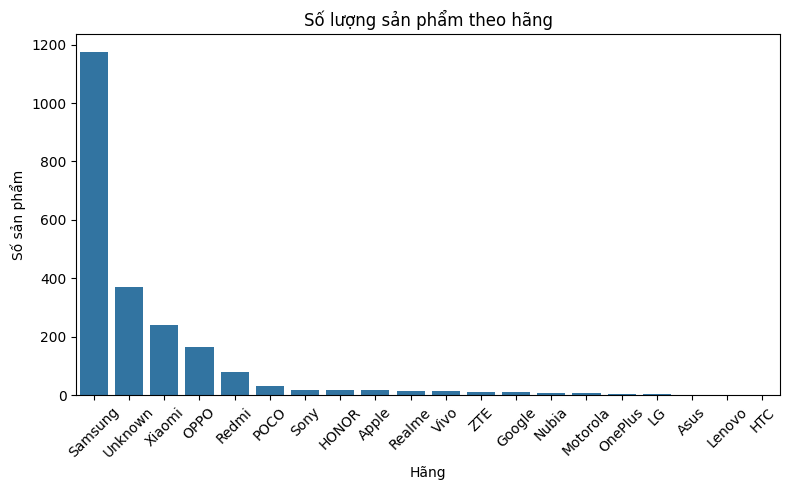

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index)
plt.title("Số lượng sản phẩm theo hãng")
plt.xlabel("Hãng")
plt.ylabel("Số sản phẩm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Biểu đồ giá trung bình theo hãng

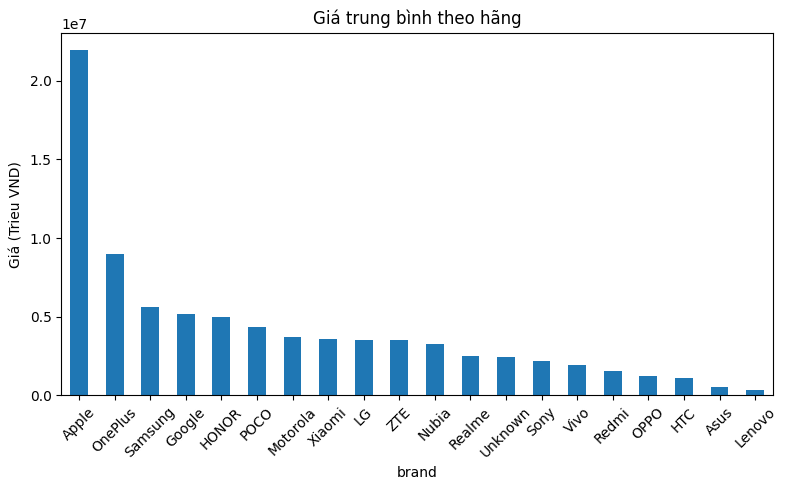

In [11]:
avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)
avg_price.plot(kind='bar', figsize=(8,5), title='Giá trung bình theo hãng')
plt.ylabel('Giá (Trieu VND)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Biểu đồ phân phối mức giảm giá

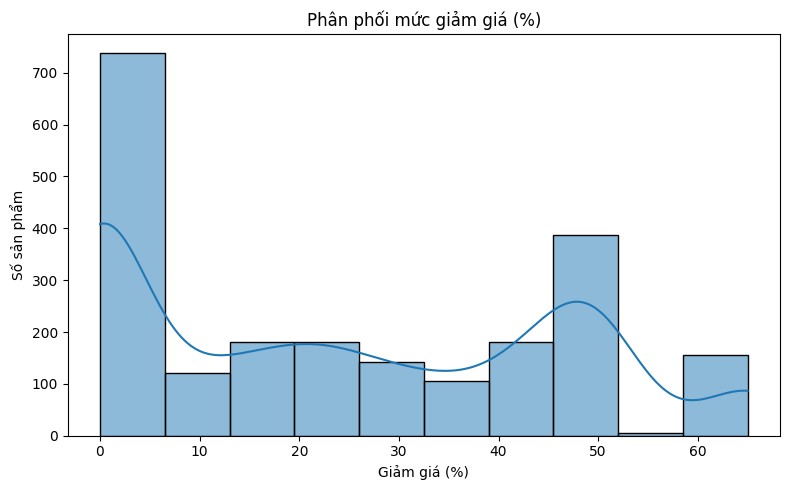

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['discount'], bins=10, kde=True)
plt.title("Phân phối mức giảm giá (%)")
plt.xlabel("Giảm giá (%)")
plt.ylabel("Số sản phẩm")
plt.tight_layout()
plt.show()


## Số sản phẩm theo khu vực

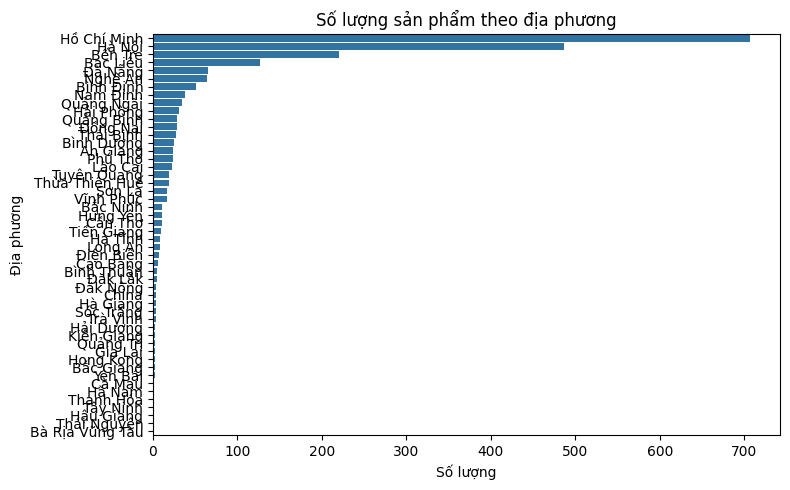

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='location', order=df['location'].value_counts().index)
plt.title("Số lượng sản phẩm theo địa phương")
plt.xlabel("Số lượng")
plt.ylabel("Địa phương")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import folium
from geopy.geocoders import Nominatim
import time

locations_count = df['location'].value_counts().reset_index()
locations_count.columns = ['location', 'count']

# Khởi tạo geolocator
geolocator = Nominatim(user_agent="vietnam_map_app")

# Thêm cột latitude và longitude
locations_count['latitude'] = None
locations_count['longitude'] = None

# Lấy tọa độ cho mỗi địa phương
for index, row in locations_count.iterrows():
    location_name = row['location']
    try:
        location = geolocator.geocode(location_name + ", Vietnam")  # Thêm ", Vietnam" để tăng độ chính xác
        if location:
            locations_count.at[index, 'latitude'] = location.latitude
            locations_count.at[index, 'longitude'] = location.longitude
        else:
            print(f"Không tìm thấy tọa độ cho {location_name}")
        time.sleep(1) 
    except Exception as e:
        print(f"Lỗi khi geocoding {location_name}: {e}")

locations_count = locations_count.dropna(subset=['latitude', 'longitude'])

vietnam_map = folium.Map(location=[14.0583, 108.2772], zoom_start=5)

max_count = locations_count['count'].max()
scaling_factor = 50000  

for index, row in locations_count.iterrows():
    radius = (row['count'] / max_count) * scaling_factor
    folium.Circle(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        popup=f"{row['location']}: {row['count']} sản phẩm",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6
    ).add_to(vietnam_map)

vietnam_map.save('vietnam_products_map.html')

vietnam_map

## Biểu đồ scatter: Giá vs RAM

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mayti\AppData\Local\Temp\ipykernel_11064\3877236022.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['ram_num'] = df['ram'].str.extract('(\d+)').astype(float)


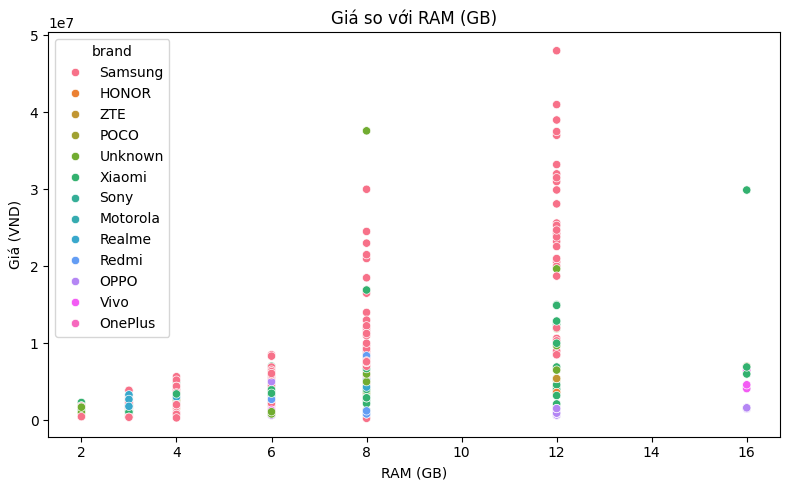

In [19]:
# Chuyển RAM thành số (nếu có GB)
df['ram_num'] = df['ram'].str.extract('(\d+)').astype(float)

df_valid_ram = df[df['ram_num'] < 32]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_valid_ram, x='ram_num', y='price', hue='brand')
plt.title("Giá so với RAM (GB)")
plt.xlabel("RAM (GB)")
plt.ylabel("Giá (VND)")
plt.tight_layout()
plt.show()


## Treemap: Hãng và số lượng sản phẩm

In [26]:
import pandas as pd
import plotly.express as px

brand_counts = df['brand'].value_counts().reset_index()
brand_counts.columns = ['brand', 'count']

threshold = 50
brand_counts['brand_grouped'] = brand_counts.apply(
    lambda row: row['brand'] if row['count'] >= threshold else 'Hãng Khác', axis=1
)

grouped_counts = brand_counts.groupby('brand_grouped')['count'].sum().reset_index()

# Tạo biểu đồ tròn
fig = px.pie(
    grouped_counts,
    values='count',
    names='brand_grouped',
    title='Tỉ lệ sản phẩm theo hãng',
    color_discrete_sequence=px.colors.qualitative.Set3 
)
# Tùy chỉnh layout
fig.update_traces(textinfo='percent+label', pull=[0.1 if x != 'Hãng Khác' else 0 for x in grouped_counts['brand_grouped']])
fig.update_layout(showlegend=True)

# Hiển thị biểu đồ
fig.show()


## Biểu đồ heatmap: Mối liên hệ giữa RAM, ROM và giá

<>:5: SyntaxWarning:

invalid escape sequence '\d'

<>:5: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\mayti\AppData\Local\Temp\ipykernel_11064\2573566597.py:5: SyntaxWarning:

invalid escape sequence '\d'



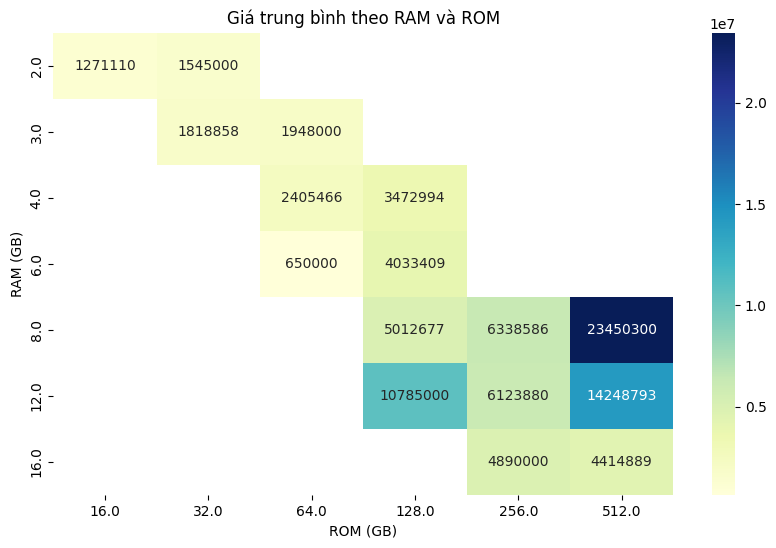

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['rom_num'] = df['rom'].str.extract('(\d+)').astype(float)

df_filtered = df[df['ram_num'] <= 40]

pivot_table = df_filtered.pivot_table(index='ram_num', columns='rom_num', values='price', aggfunc='mean')

# Vẽ heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Giá trung bình theo RAM và ROM")
plt.xlabel("ROM (GB)")
plt.ylabel("RAM (GB)")
plt.show()